# Investigation 02 - 4D Metric Correlation Bubble Plot


In [65]:
import ast
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Rectangle

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120


In [ ]:
# ---------- Main toggles ----------
METHOD = "CN"
ORGAN = "Colon"   # "Colon", "Duodenum", or None
ORGAN_COLUMN = "Organ"
NO_SELF = True
SUBSET_RULE_ITEMS_MAX = 2
SUBSET_MIN_SUPPORT = 0.02
STAGE_COLUMN = "Pathological score"
FDR_COLUMN = "FDR"
FDR_MAX = 0.05

STAGE = "Mild"  # e.g., "Control", "Mild", "Severe", or 0, 1, 2
# ---------- Bubble thresholds ----------
POS_LEVERAGE_MIN = 0.05
POS_LIFT_MIN = 1.2
NEG_LEVERAGE_MAX = -0.05
NEG_LIFT_MAX = 0.6

# ---------- Bubble display ----------
MIN_SUPPORT_FOR_BUBBLE = 0.0
BUBBLE_SIZE_SCALE = 2000
NOISE_LEVERAGE_ABS = 0.01
NOISE_LIFT_RANGE = (0.8, 1.2)

# ---------- Data path ----------
ALGO = "weighted_fpgrowth_old"  # e.g., "fpgrowth", "weighted_fpgrowth"
DATA_ROOT = fr"results\full_run\{ALGO}\data"
RAW_RESULTS_FILE = os.path.join("..", "..", DATA_ROOT, f"results_{METHOD}.csv")

print("METHOD:", METHOD)
print("ORGAN:", ORGAN)
print("NO_SELF:", NO_SELF)
print("SUBSET_RULE_ITEMS_MAX:", SUBSET_RULE_ITEMS_MAX)
print("SUBSET_MIN_SUPPORT:", SUBSET_MIN_SUPPORT)
print("FDR_MAX:", FDR_MAX)
print("RAW_RESULTS_FILE:", RAW_RESULTS_FILE)

# ---------- Highlight specific rules ----------
HIGHLIGHT_RULES = [
    r"Paneth.*->.*Epithelial.*",
    r"Macrophage.*->.*Epithelial.*",
    r"Plasma.*->.*Epithelial.*",
    r"CD8T.*->.*Epithelial.*",
    r"Neutrophil.*->.*Epithelial.*",
    r"Macrophage.*-> CD8T.*",
    r"Endocrine.*->.*Muscle.*",
    r"Fibroblast.*->.*Epithelial.*"
]


METHOD: CN
ORGAN: Colon
NO_SELF: True
SUBSET_RULE_ITEMS_MAX: 2
SUBSET_MIN_SUPPORT: 0.02
FDR_MAX: 0.05
RAW_RESULTS_FILE: ..\..\results\full_run\weighted_fpgrowth_old\data\results_CN.csv


In [67]:
def _plot_metric_bubble(metric_df, leverage_source):
    if metric_df.empty:
        print("No rows after filtering. Adjust filters or thresholds.")
        return None

    fig, ax = plt.subplots(figsize=(14, 10))

    scatter = ax.scatter(
        metric_df["Leverage"],
        metric_df["Log2_Lift"],
        s=metric_df["Bubble_Size"],
        c=metric_df["Confidence"],
        cmap="viridis",
        alpha=0.75,
        edgecolors="black",
        linewidths=0.3,
    )

    ax.axvline(0, color="gray", linewidth=1.0)
    ax.axhline(0, color="gray", linewidth=1.0)
    ax.axvline(POS_LEVERAGE_MIN, color="tomato", linestyle="--", linewidth=1.0)
    ax.axhline(np.log2(POS_LIFT_MIN), color="tomato", linestyle="--", linewidth=1.0)
    ax.axvline(NEG_LEVERAGE_MAX, color="royalblue", linestyle="--", linewidth=1.0)
    ax.axhline(np.log2(NEG_LIFT_MAX), color="royalblue", linestyle="--", linewidth=1.0)

    x_min, x_max = metric_df["Leverage"].min(), metric_df["Leverage"].max()
    y_min, y_max = metric_df["Log2_Lift"].min(), metric_df["Log2_Lift"].max()

    if x_max > POS_LEVERAGE_MIN and y_max > np.log2(POS_LIFT_MIN):
        pos_rect = Rectangle(
            (POS_LEVERAGE_MIN, np.log2(POS_LIFT_MIN)),
            x_max - POS_LEVERAGE_MIN,
            y_max - np.log2(POS_LIFT_MIN),
            fill=False,
            edgecolor="tomato",
            linewidth=1.2,
        )
        ax.add_patch(pos_rect)

    if x_min < NEG_LEVERAGE_MAX and y_min < np.log2(NEG_LIFT_MAX):
        neg_rect = Rectangle(
            (x_min, y_min),
            NEG_LEVERAGE_MAX - x_min,
            np.log2(NEG_LIFT_MAX) - y_min,
            fill=False,
            edgecolor="royalblue",
            linewidth=1.2,
        )
        ax.add_patch(neg_rect)

    colorbar = plt.colorbar(scatter, ax=ax)
    colorbar.set_label("Confidence")

    # --- Highlight specific rules ---
    if "HIGHLIGHT_RULES" in globals() and HIGHLIGHT_RULES:
        import re
        pattern = "|".join(HIGHLIGHT_RULES)
        mask = metric_df["Rule"].str.contains(pattern, regex=True, na=False)
        hl_df = metric_df[mask]
        if not hl_df.empty:
            ax.scatter(
                hl_df["Leverage"],
                hl_df["Log2_Lift"],
                s=hl_df["Bubble_Size"],
                facecolors="none",
                edgecolors="red",
                linewidths=2.5,
                zorder=5,
            )
            from adjustText import adjust_text
            texts = []
            for _, row in hl_df.iterrows():
                texts.append(ax.text(
                    row["Leverage"],
                    row["Log2_Lift"],
                    row["Rule"],
                    color="red",
                    fontsize=9,
                    zorder=6,
                ))
            adjust_text(texts, arrowprops=dict(arrowstyle="-", color='red', lw=0.5))

    supports = metric_df["Support"].quantile([0.1, 0.5, 0.75, 0.9]).values
    handles = [
        ax.scatter([], [], s=max(s * BUBBLE_SIZE_SCALE, 10), color="gray", alpha=0.35, edgecolors="none")
        for s in supports
    ]
    labels = [f"Support {s:.3f}" for s in supports]
    ax.legend(handles, labels, title="Bubble size", loc="upper left")

    positive_count = int(((metric_df["Leverage"] >= POS_LEVERAGE_MIN) & (metric_df["Log2_Lift"] >= np.log2(POS_LIFT_MIN))).sum())
    negative_count = int(((metric_df["Leverage"] <= NEG_LEVERAGE_MAX) & (metric_df["Log2_Lift"] <= np.log2(NEG_LIFT_MAX))).sum())
    dot_count = int(metric_df.shape[0])

    organ_text = ORGAN if ORGAN is not None else "All"
    stage_text = STAGE if STAGE is not None else "All"
    
    title_lines = [
        f"4D Metric Correlation Bubble Plot ({METHOD} | {ALGO})",
        f"Organ: {organ_text}  |  Stage Col: {STAGE_COLUMN}  |  Stage: {stage_text}",
        f"Filters: No Self-Loops={NO_SELF}  |  Max Items={SUBSET_RULE_ITEMS_MAX}  |  Min Support={SUBSET_MIN_SUPPORT}  |  FDR < {FDR_MAX}"
    ]
    
    ax.set_title(
        "\n".join(title_lines), 
        pad=20, loc="left", fontsize=11, fontweight="bold", linespacing=1.5
    )
    ax.set_xlabel("Leverage")
    ax.set_ylabel("log2(Lift)")
    ax.text(
        0.01,
        -0.12,
        f"Dots: {dot_count} | Positive: {positive_count} | Negative: {negative_count}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
    )
    fig.subplots_adjust(bottom=0.16)

    return fig


def _summarize_threshold_zones(metric_df):
    positive_zone = (metric_df["Leverage"] >= POS_LEVERAGE_MIN) & (metric_df["Log2_Lift"] >= np.log2(POS_LIFT_MIN))
    negative_zone = (metric_df["Leverage"] <= NEG_LEVERAGE_MAX) & (metric_df["Log2_Lift"] <= np.log2(NEG_LIFT_MAX))
    noise_zone = (metric_df["Leverage"].abs() <= NOISE_LEVERAGE_ABS) & ((metric_df["Lift"] >= NOISE_LIFT_RANGE[0]) & (metric_df["Lift"] <= NOISE_LIFT_RANGE[1]))

    summary = pd.DataFrame(
        {
            "Zone": ["Positive zone", "Negative zone", "Noise zone", "Total"],
            "Count": [int(positive_zone.sum()), int(negative_zone.sum()), int(noise_zone.sum()), int(metric_df.shape[0])],
        }
    )
    summary["Percent"] = (summary["Count"] / max(metric_df.shape[0], 1) * 100).round(2)
    return summary



def _add_organ_metadata(work_df):
    import os
    import pandas as pd
    
    if "Organ" in work_df.columns:
        return work_df
        
    mibi_gut_dir_path = os.path.join("..", "..", "data", "MIBIGutCsv")
    biopsy_path = os.path.join(mibi_gut_dir_path, "biopsy_metadata.csv")
    fovs_path = os.path.join(mibi_gut_dir_path, "fovs_metadata.csv")

    if os.path.exists(biopsy_path) and os.path.exists(fovs_path):
        df_biopsy = pd.read_csv(biopsy_path)
        df_fovs = pd.read_csv(fovs_path)
        unique_biopsies = df_fovs[~df_fovs["FOV"].astype(str).str.startswith("S_")][["Patient", "Cohort"]].drop_duplicates().rename(columns={"Patient": "Biopsy_ID"})
        meta = pd.merge(unique_biopsies, df_biopsy[["Biopsy_ID", "Localization"]], on="Biopsy_ID", how="left")

        def get_organ(row):
            if pd.notna(row.get("Localization")): return row["Localization"]
            cohort = str(row.get("Cohort", ""))
            if "Colon" in cohort: return "Colon"
            if "Duodenum" in cohort: return "Duodenum"
            return "Unknown"

        meta["Organ"] = meta.apply(get_organ, axis=1)
        work_df = work_df.merge(meta[["Biopsy_ID", "Organ"]], on="Biopsy_ID", how="left")
    return work_df



def _plot_highlight_rules_table(organ):
    import re
    import numpy as np
    import ast
    import matplotlib.pyplot as plt
    from pandas.plotting import table

    if not "HIGHLIGHT_RULES" in globals() or not HIGHLIGHT_RULES:
        return None

    pattern = "|".join(HIGHLIGHT_RULES)
    test_df = raw_results_df.copy()
    test_df = _add_organ_metadata(test_df)
    
    if organ is not None:
        test_df = test_df[test_df["Organ"].astype(str) == str(organ)].copy()
        
    test_df["Item_Count"] = (
        test_df["Antecedents"].apply(ast.literal_eval).apply(len) +
        test_df["Consequents"].apply(ast.literal_eval).apply(len)
    )

    test_df["Rule_Clean"] = (
        test_df["Antecedents"].astype(str).str.replace("_CENTER", "").str.replace("_NEIGHBOR", "").str.replace("['", "").str.replace("']", "")
        + " -> " +
        test_df["Consequents"].astype(str).str.replace("_CENTER", "").str.replace("_NEIGHBOR", "").str.replace("['", "").str.replace("']", "")
    )

    if SUBSET_RULE_ITEMS_MAX is not None:
        test_df = test_df[test_df["Item_Count"] <= SUBSET_RULE_ITEMS_MAX]
        
    highlight_mask = test_df["Rule_Clean"].str.contains(pattern, regex=True, na=False)
    hl_df = test_df[highlight_mask].copy()

    if hl_df.empty:
        return None

    hl_df["Leverage"] = hl_df["Support"] * (1 - 1 / hl_df["Lift"])
    stats_df = hl_df.groupby(["Rule_Clean", STAGE_COLUMN]).agg(
        FOV_Count=("FOV", "nunique"),
        Mean_Leverage=("Leverage", "mean"),
        Mean_Lift=("Lift", "mean"),
        Mean_Confidence=("Confidence", "mean"),
        Mean_Support=("Support", "mean")
    ).reset_index()

    for col in ["Mean_Leverage", "Mean_Lift", "Mean_Confidence", "Mean_Support"]:
        if col in stats_df.columns:
            stats_df[col] = stats_df[col].round(3)

    import textwrap
    stats_df["Rule_Clean"] = stats_df["Rule_Clean"].apply(lambda x: textwrap.fill(x, width=45))

    fig, ax = plt.subplots(figsize=(14, max(2, len(stats_df) * 0.7)))
    ax.axis("off")
    
    col_labels = stats_df.columns.tolist()
    cell_text = stats_df.values.tolist()
    col_widths = [0.4, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]
    
    tbl = ax.table(cellText=cell_text, colLabels=col_labels, loc="center", cellLoc="center", colWidths=col_widths)
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 3.0)
    
    for key, cell in tbl.get_celld().items():
        cell.set_edgecolor('lightgray')
        if key[0] == 0:
            cell.set_text_props(weight='bold')
            cell.set_facecolor('#f2f2f2')
    
    title_text = f"Highlighted Rules Metrics ({METHOD} | {ALGO}) | Organ: {organ} | Items <= {SUBSET_RULE_ITEMS_MAX}"
    ax.set_title(title_text, pad=20, loc="center", fontsize=12, fontweight="bold")
    
    return fig


### Load Raw Data

In [68]:
raw_results_df = pd.read_csv(RAW_RESULTS_FILE)
raw_results_df = raw_results_df[raw_results_df["FDR"] <= FDR_MAX].copy()
print("raw_results_df:", raw_results_df.shape)
raw_results_df.head(3)


raw_results_df: (65938, 22)


,FOV,Antecedents,Consequents,Lift,Confidence,Conviction,Support,P_Value,FDR,Rule_Count_Global,...,Cortico Response,Survival at follow-up,GI stage,Grade GVHD,liver stage,skin stage,Pathological stage,Clinical score,Pathological score,Group
0,Control_01_FOV_1,['Paneth_CENTER'],['Paneth_NEIGHBOR'],11.122259,0.950494,18.473508,0.011410,0.000999,0.001234,60,...,Control,Control,0.0,0.0,0.0,0.0,0.0,Control,Control,0.0
1,Control_01_FOV_1,['Paneth_CENTER'],"['Epithelial_NEIGHBOR', 'Paneth_NEIGHBOR']",11.415205,0.950494,18.517808,0.011410,0.000999,0.001234,53,...,Control,Control,0.0,0.0,0.0,0.0,0.0,Control,Control,0.0
2,Control_01_FOV_1,['Paneth_CENTER'],['Epithelial_NEIGHBOR'],2.249347,1.000000,inf,0.012005,0.000999,0.001234,31,...,Control,Control,0.0,0.0,0.0,0.0,0.0,Control,Control,0.0


In [69]:
import re
import numpy as np

ORGAN = "Colon"   # "Colon", "Duodenum", or None
pattern = "|".join(HIGHLIGHT_RULES)
print("Regex pattern for highlighting:", pattern)

# 1. Create a clean rule string directly on the raw data (bypassing all filters)
test_df = raw_results_df.copy()
test_df = _add_organ_metadata(test_df)
if ORGAN is not None:
    test_df = test_df[test_df["Organ"].astype(str) == str(ORGAN)].copy()
test_df["Item_Count"] = (
    test_df["Antecedents"].apply(ast.literal_eval).apply(len) +
    test_df["Consequents"].apply(ast.literal_eval).apply(len)
)

test_df["Rule_Clean"] = (
    test_df["Antecedents"].astype(str).str.replace("_CENTER", "").str.replace("_NEIGHBOR", "").str.replace("['", "").str.replace("']", "")
    + " -> " +
    test_df["Consequents"].astype(str).str.replace("_CENTER", "").str.replace("_NEIGHBOR", "").str.replace("['", "").str.replace("']", "")
    )

test_df = test_df[test_df["Item_Count"] <= SUBSET_RULE_ITEMS_MAX]
# 2. Search for the pattern
highlight_mask = test_df["Rule_Clean"].str.contains(pattern, regex=True, na=False)
matching_rows = test_df[highlight_mask]

# Extract just the rows for your highlighted rules
hl_df = test_df[highlight_mask].copy()

if not hl_df.empty:
    # 1. Calculate Leverage for each FOV (Support * (1 - 1/Lift))
    hl_df["Leverage"] = hl_df["Support"] * (1 - 1 / hl_df["Lift"])

    # 2. Group by Rule and Stage to calculate means AND count the unique FOVs
    stats_df = hl_df.groupby(["Rule_Clean", STAGE_COLUMN]).agg(
        FOV_Count=("FOV", "nunique"),
        Mean_Leverage=("Leverage", "mean"),
        Mean_Lift=("Lift", "mean"),
        Mean_Confidence=("Confidence", "mean"),
        Mean_Support=("Support", "mean")
    ).reset_index()

    print(f"\n--- Metrics per Stage for '{ORGAN}' ---")
    display(stats_df)
else:
    print(f"\n--- No matching rules found for '{ORGAN}' in this filtered dataset ---")

Regex pattern for highlighting: Paneth.*->.*Epithelial.*|Macrophage.*->.*Epithelial.*|Plasma.*->.*Epithelial.*|CD8T.*->.*Epithelial.*|Neutrophil.*->.*Epithelial.*|Macrophage.*-> CD8T.*|Endocrine.*->.*Muscle.*|Fibroblast.*->.*Epithelial.*

--- Metrics per Stage for 'Colon' ---


,Rule_Clean,Clinical score,FOV_Count,Mean_Leverage,Mean_Lift,Mean_Confidence,Mean_Support
0,CD8T -> Epithelial,Mild,1,-0.009758,0.562619,0.463448,0.012552
1,CD8T -> Epithelial,Severe,2,-0.015620,0.612445,0.208908,0.024763
2,Fibroblast -> Epithelial,Severe,4,-0.036196,0.606063,0.331728,0.065354
3,Macrophage -> CD8T,Severe,2,0.028888,1.222946,0.742206,0.160006
4,Macrophage -> Epithelial,Control,4,-0.028635,0.655538,0.309169,0.053828
5,Macrophage -> Epithelial,Mild,1,-0.023254,0.683676,0.492072,0.050259
6,Macrophage -> Epithelial,Severe,7,-0.043115,0.639333,0.378985,0.082031
7,Macrophage -> FibroticEpithelial,Severe,1,0.021211,1.248056,0.753049,0.106719
8,Macrophage_Calp -> CD8T,Severe,1,0.008440,1.730824,0.768351,0.019989
9,Macrophage_Calp -> Epithelial,Mild,1,-0.025347,0.343859,0.285326,0.013283


In [70]:
import re
import numpy as np

ORGAN = "Duodenum"   # "Colon", "Duodenum", or None
pattern = "|".join(HIGHLIGHT_RULES)
print("Regex pattern for highlighting:", pattern)

# 1. Create a clean rule string directly on the raw data (bypassing all filters)
test_df = raw_results_df.copy()
test_df = _add_organ_metadata(test_df)
if ORGAN is not None:
    test_df = test_df[test_df["Organ"].astype(str) == str(ORGAN)].copy()
test_df["Item_Count"] = (
    test_df["Antecedents"].apply(ast.literal_eval).apply(len) +
    test_df["Consequents"].apply(ast.literal_eval).apply(len)
)

test_df["Rule_Clean"] = (
    test_df["Antecedents"].astype(str).str.replace("_CENTER", "").str.replace("_NEIGHBOR", "").str.replace("['", "").str.replace("']", "")
    + " -> " +
    test_df["Consequents"].astype(str).str.replace("_CENTER", "").str.replace("_NEIGHBOR", "").str.replace("['", "").str.replace("']", "")
    )

test_df = test_df[test_df["Item_Count"] <= SUBSET_RULE_ITEMS_MAX]
# 2. Search for the pattern
highlight_mask = test_df["Rule_Clean"].str.contains(pattern, regex=True, na=False)
matching_rows = test_df[highlight_mask]

# Extract just the rows for your highlighted rules
hl_df = test_df[highlight_mask].copy()

if not hl_df.empty:
    # 1. Calculate Leverage for each FOV (Support * (1 - 1/Lift))
    hl_df["Leverage"] = hl_df["Support"] * (1 - 1 / hl_df["Lift"])

    # 2. Group by Rule and Stage to calculate means AND count the unique FOVs
    stats_df = hl_df.groupby(["Rule_Clean", STAGE_COLUMN]).agg(
        FOV_Count=("FOV", "nunique"),
        Mean_Leverage=("Leverage", "mean"),
        Mean_Lift=("Lift", "mean"),
        Mean_Confidence=("Confidence", "mean"),
        Mean_Support=("Support", "mean")
    ).reset_index()

    print(f"\n--- Metrics per Stage for '{ORGAN}' ---")
    display(stats_df)
else:
    print(f"\n--- No matching rules found for '{ORGAN}' in this filtered dataset ---")

Regex pattern for highlighting: Paneth.*->.*Epithelial.*|Macrophage.*->.*Epithelial.*|Plasma.*->.*Epithelial.*|CD8T.*->.*Epithelial.*|Neutrophil.*->.*Epithelial.*|Macrophage.*-> CD8T.*|Endocrine.*->.*Muscle.*|Fibroblast.*->.*Epithelial.*

--- Metrics per Stage for 'Duodenum' ---


,Rule_Clean,Clinical score,FOV_Count,Mean_Leverage,Mean_Lift,Mean_Confidence,Mean_Support
0,CD8T -> Epithelial,Control,1,-0.015239,0.592411,0.429487,0.022150
1,CD8T -> Epithelial,Mild,1,-0.025936,0.692529,0.411742,0.058417
2,CD8T -> Epithelial,Severe,3,-0.012074,0.614081,0.333740,0.019302
3,Fibroblast -> Epithelial,Control,5,-0.020075,0.625205,0.391949,0.034401
4,Fibroblast -> Epithelial,Mild,8,-0.024893,0.685815,0.428770,0.049036
5,Fibroblast -> Epithelial,Severe,4,-0.021966,0.627089,0.330212,0.036495
6,Macrophage -> CD8T,Severe,1,0.022596,1.368483,0.717378,0.083916
7,Macrophage -> Epithelial,Control,2,-0.039360,0.634884,0.457992,0.070009
8,Macrophage -> Epithelial,Mild,4,-0.025065,0.610080,0.398511,0.041907
9,Macrophage_Calp -> Epithelial,Control,2,-0.007612,0.587327,0.417547,0.010748


### Build Filtered Bubble Table

In [71]:
def _to_lineage(cell_label):
    cell_label = str(cell_label)
    if cell_label.endswith("+") and "_" in cell_label:
        return cell_label.rsplit("_", 1)[0]
    return cell_label


def _create_basic_dataset(raw_results_df):
    work_df = raw_results_df.copy()

    # --- Standardized Organ Enrichment (Inlined from visualization_util logic) ---
    mibi_gut_dir_path = os.path.join("..", "..", "data", "MIBIGutCsv")
    biopsy_path = os.path.join(mibi_gut_dir_path, "biopsy_metadata.csv")
    fovs_path = os.path.join(mibi_gut_dir_path, "fovs_metadata.csv")
    
    if os.path.exists(biopsy_path) and os.path.exists(fovs_path):
        df_biopsy = pd.read_csv(biopsy_path)
        df_fovs = pd.read_csv(fovs_path)
        unique_biopsies = df_fovs[~df_fovs["FOV"].astype(str).str.startswith("S_")][["Patient", "Cohort"]].drop_duplicates().rename(columns={"Patient": "Biopsy_ID"})
        meta = pd.merge(unique_biopsies, df_biopsy[["Biopsy_ID", "Localization"]], on="Biopsy_ID", how="left")
        
        def get_organ(row):
            if pd.notna(row.get("Localization")): return row["Localization"]
            cohort = str(row.get("Cohort", ""))
            if "Colon" in cohort: return "Colon"
            if "Duodenum" in cohort: return "Duodenum"
            return "Unknown"
        
        meta["Organ"] = meta.apply(get_organ, axis=1)
        work_df = work_df.merge(meta[["Biopsy_ID", "Organ"]], on="Biopsy_ID", how="left")
    # -----------------------------------------------------------------------------

    work_df["ant_items"] = work_df["Antecedents"].apply(ast.literal_eval)
    work_df["con_items"] = work_df["Consequents"].apply(ast.literal_eval)
    work_df["ant_clean"] = work_df["ant_items"].apply(
        lambda items: [str(x).replace("_CENTER", "").replace("_NEIGHBOR", "") for x in items]
    )
    work_df["con_clean"] = work_df["con_items"].apply(
        lambda items: [str(x).replace("_CENTER", "").replace("_NEIGHBOR", "") for x in items]
    )
    work_df["ant_lineage"] = work_df["ant_clean"].apply(lambda items: [_to_lineage(x) for x in items])
    work_df["con_lineage"] = work_df["con_clean"].apply(lambda items: [_to_lineage(x) for x in items])
    print(f"Initial rules count: {work_df.shape[0]}")

    if NO_SELF:
        has_overlap = work_df.apply(
            lambda row: len(set(row["ant_lineage"]).intersection(set(row["con_lineage"]))) > 0,
            axis=1,
        )
        work_df = work_df[~has_overlap].copy()
        print(f"Rules count after removing self-overlapping rules: {work_df.shape[0]}")

    if SUBSET_RULE_ITEMS_MAX is not None:
        rule_item_count = work_df.apply(lambda row: len(row["ant_clean"]) + len(row["con_clean"]), axis=1)
        work_df = work_df[rule_item_count <= int(SUBSET_RULE_ITEMS_MAX)].copy()
        print(f"Rules count after filtering by subset rule items: {work_df.shape[0]}")

    if SUBSET_MIN_SUPPORT is not None:
        work_df = work_df[work_df["Support"] >= float(SUBSET_MIN_SUPPORT)].copy()
        print(f"Rules count after filtering by minimum support: {work_df.shape[0]}")

    if STAGE is not None:
        work_df = work_df[work_df[STAGE_COLUMN].astype(str) == str(STAGE)].copy()
        print(f"Rules count after filtering by stage: {work_df.shape[0]}")

    if ORGAN is not None:
        work_df = work_df[work_df["Organ"].astype(str) == str(ORGAN)].copy()
        print(f"Rules count after filtering by organ: {work_df.shape[0]}")

    # --- Safeguard --- 
    if work_df.empty:
        print("Dataset is empty after filtering! Returning early.")
        return work_df
    # -----------------

    work_df["Rule"] = work_df.apply(
        lambda row: f"{', '.join(row['ant_clean'])} -> {', '.join(row['con_clean'])}",
        axis=1,
    )

    return work_df


def _build_metric_bubble_df(work_df):

    if work_df.empty:
        print("Input work_df is empty. Returning empty metric_df.")
        raise ValueError("Input work_df is empty. Cannot build metric_df.")

    metric_df = work_df.copy()
    metric_df = metric_df[metric_df[FDR_COLUMN] < FDR_MAX].copy()
    
    # Defensive checks on the base metrics used in the plot
    metric_df = metric_df[np.isfinite(metric_df["Lift"])].copy()
    metric_df = metric_df[np.isfinite(metric_df["Confidence"])].copy()
    metric_df = metric_df[np.isfinite(metric_df["Support"])].copy()
    metric_df = metric_df[metric_df["Lift"] > 0].copy()

    # 1. Calculate per-FOV metrics FIRST
    # leverage = support - expected_support, and expected_support = support / lift
    metric_df["Leverage"] = metric_df["Support"] * (1 - 1 / metric_df["Lift"])
    
    # Defensive checks on the derived metrics
    metric_df = metric_df[np.isfinite(metric_df["Leverage"])].copy()

    # 2. THEN group by Rule to get the true mathematical mean of all values
    print("metric_df number of lines:", metric_df.shape[0])
    metric_df = metric_df.groupby("Rule", as_index=False)[
        ["Lift", "Confidence", "Support", "Leverage", FDR_COLUMN]
    ].mean()

    metric_df["Log2_Lift"] = np.log2(metric_df["Lift"])
    metric_df = metric_df[np.isfinite(metric_df["Log2_Lift"])].copy()

    # 3. Apply final display filters
    metric_df = metric_df[metric_df["Support"] >= MIN_SUPPORT_FOR_BUBBLE].copy()
    metric_df["Bubble_Size"] = (metric_df["Support"] * BUBBLE_SIZE_SCALE).clip(lower=10)
    
    leverage_source = "mean of per-FOV Leverage"

    return metric_df, leverage_source

    

In [72]:
def _build_and_display_filtered_zone_dataset(metric_df):

    display_cols = ["Rule", "Leverage", "Lift", "Log2_Lift", "Confidence", "Support"]

    # --- Extract and Display Rules for a Selected Zone ---

    # Positive zone:
    zone_mask = (metric_df["Leverage"] >= POS_LEVERAGE_MIN) & (metric_df["Log2_Lift"] >= np.log2(POS_LIFT_MIN))
    sort_col = "Leverage"
    asc = False

    zone_df = metric_df[zone_mask].copy()
    zone_df_display = zone_df[display_cols].sort_values(by=sort_col, ascending=asc)

    print(f"Rules in Positive Zone: {len(zone_df_display)}")
    display(zone_df_display.style.background_gradient(cmap='viridis', subset=["Leverage", "Lift", "Log2_Lift", "Confidence", "Support"]))

    # Negative zone:
    zone_mask = (metric_df["Leverage"] <= NEG_LEVERAGE_MAX) & (metric_df["Log2_Lift"] <= np.log2(NEG_LIFT_MAX))
    sort_col = "Leverage"
    asc = True
    
    zone_df = metric_df[zone_mask].copy()
    zone_df_display = zone_df[display_cols].sort_values(by=sort_col, ascending=asc)

    print(f"Rules in Negative Zone: {len(zone_df_display)}")
    display(zone_df_display.style.background_gradient(cmap='viridis', subset=["Leverage", "Lift", "Log2_Lift", "Confidence", "Support"]))


## Colon's Highest Rules

Initial rules count: 65938
Rules count after removing self-overlapping rules: 46016
Rules count after filtering by subset rule items: 5044
Rules count after filtering by minimum support: 3392
Rules count after filtering by stage: 1074
Rules count after filtering by organ: 323
metric_df number of lines: 323
filtered work_df: (323, 30)
metric_df (after FDR + metric filters): (54, 8)
leverage_source: mean of per-FOV Leverage
                 Rule      Lift  Confidence   Support  Leverage       FDR  \
0       Bcell -> CD4T  3.510580    0.849001  0.032371  0.023150  0.001227   
1        CD4T -> CD8T  1.397728    0.785603  0.043188  0.012325  0.002753   
2  CD4T -> Fibroblast  1.236298    0.856082  0.033548  0.006412  0.001005   
3      CD4T -> Goblet  0.632864    0.451241  0.022333 -0.012956  0.001593   
4  CD4T -> Macrophage  1.282464    0.891288  0.040144  0.008702  0.001513   
5      CD4T -> Plasma  1.385419    0.785872  0.037444  0.009969  0.001551   
6  CD8T -> Fibroblast  1.272474    

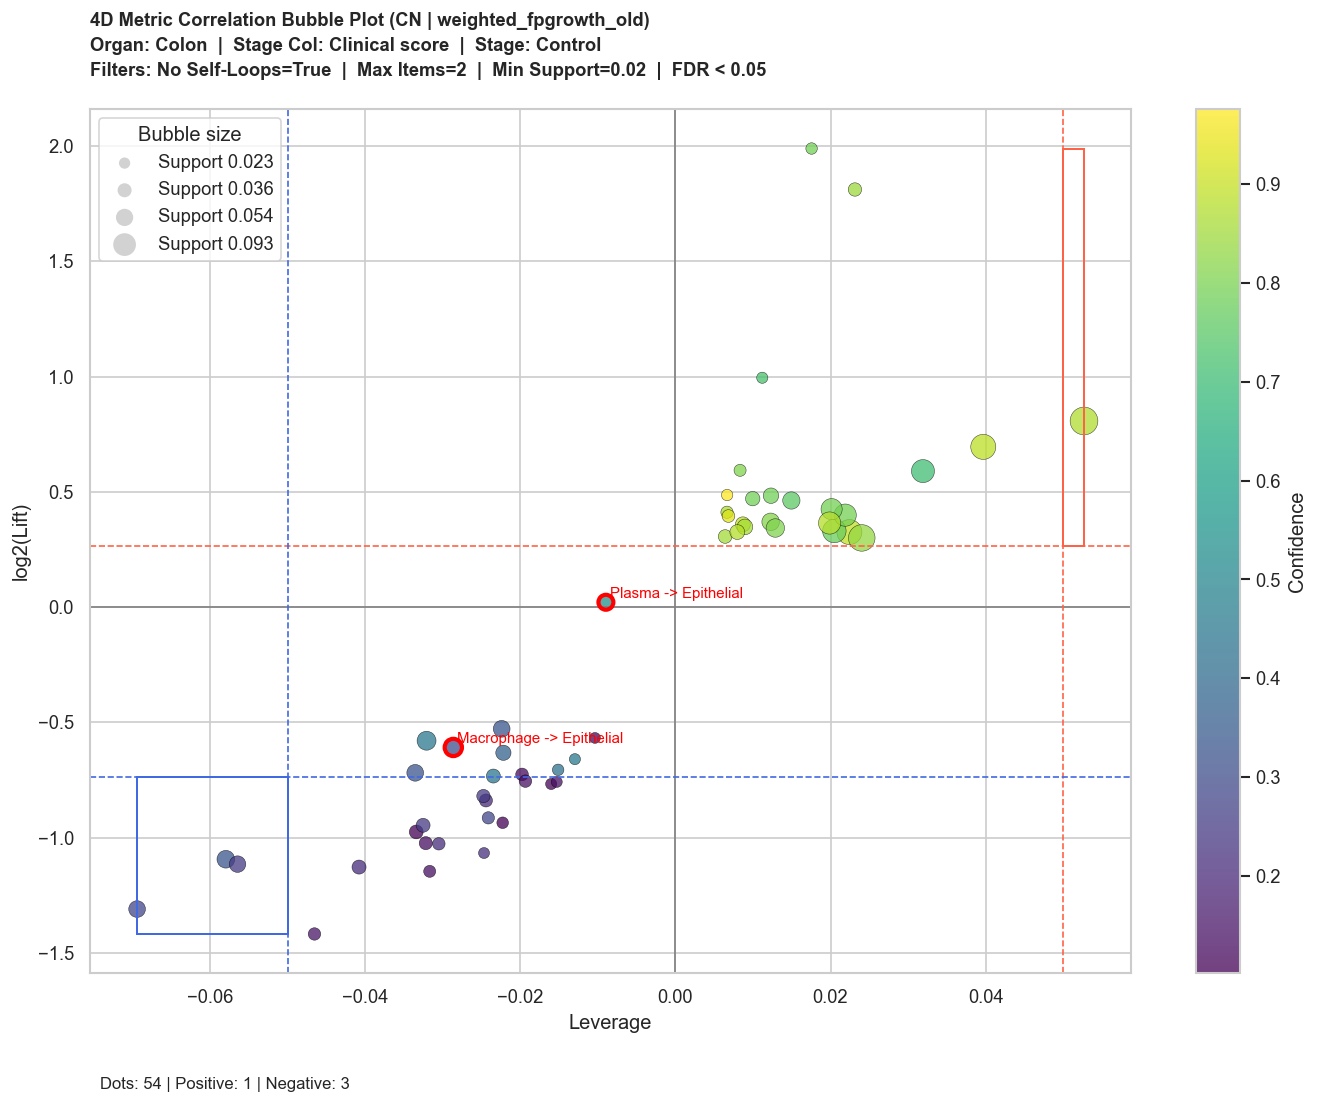

Rules in Positive Zone: 1


,Rule,Leverage,Lift,Log2_Lift,Confidence,Support
12,Epithelial -> Goblet,0.052685,1.749997,0.807353,0.872884,0.138496


Rules in Negative Zone: 3


,Rule,Leverage,Lift,Log2_Lift,Confidence,Support
27,Goblet -> Macrophage,-0.069407,0.403177,-1.310515,0.285477,0.050239
26,Goblet -> Fibroblast,-0.057964,0.468383,-1.094239,0.334080,0.056545
29,Goblet -> Plasma,-0.056456,0.461539,-1.115476,0.251874,0.049270


In [73]:
STAGE = "Control"  # Update this to test different stages
ORGAN = "Colon" 
work_df = _create_basic_dataset(raw_results_df)
metric_df, leverage_source = _build_metric_bubble_df(work_df)

print("filtered work_df:", work_df.shape)
print("metric_df (after FDR + metric filters):", metric_df.shape)
print("leverage_source:", leverage_source)

print(metric_df.head(8))


plot_figure = _plot_metric_bubble(metric_df, leverage_source)
plt.show()

_build_and_display_filtered_zone_dataset(metric_df)

Initial rules count: 65938
Rules count after removing self-overlapping rules: 46016
Rules count after filtering by subset rule items: 5044
Rules count after filtering by minimum support: 3392
Rules count after filtering by stage: 1419
Rules count after filtering by organ: 187
metric_df number of lines: 187
filtered work_df: (187, 30)
metric_df (after FDR + metric filters): (54, 8)
leverage_source: mean of per-FOV Leverage
                       Rule      Lift  Confidence   Support  Leverage  \
0        CD4T -> Epithelial  0.685555    0.443586  0.085575 -0.039251   
1            CD4T -> Goblet  0.412677    0.181278  0.032950 -0.044176   
2              CD4T -> Treg  1.493961    0.800312  0.116026  0.032329   
3        CD8T -> Macrophage  1.304931    0.835783  0.046750  0.010454   
4               CD8T -> SMV  1.439366    0.756174  0.020481  0.006252   
5        Epithelial -> CD4T  0.644306    0.250675  0.051533 -0.026541   
6        Epithelial -> CD8T  0.505475    0.114780  0.025114 -0.

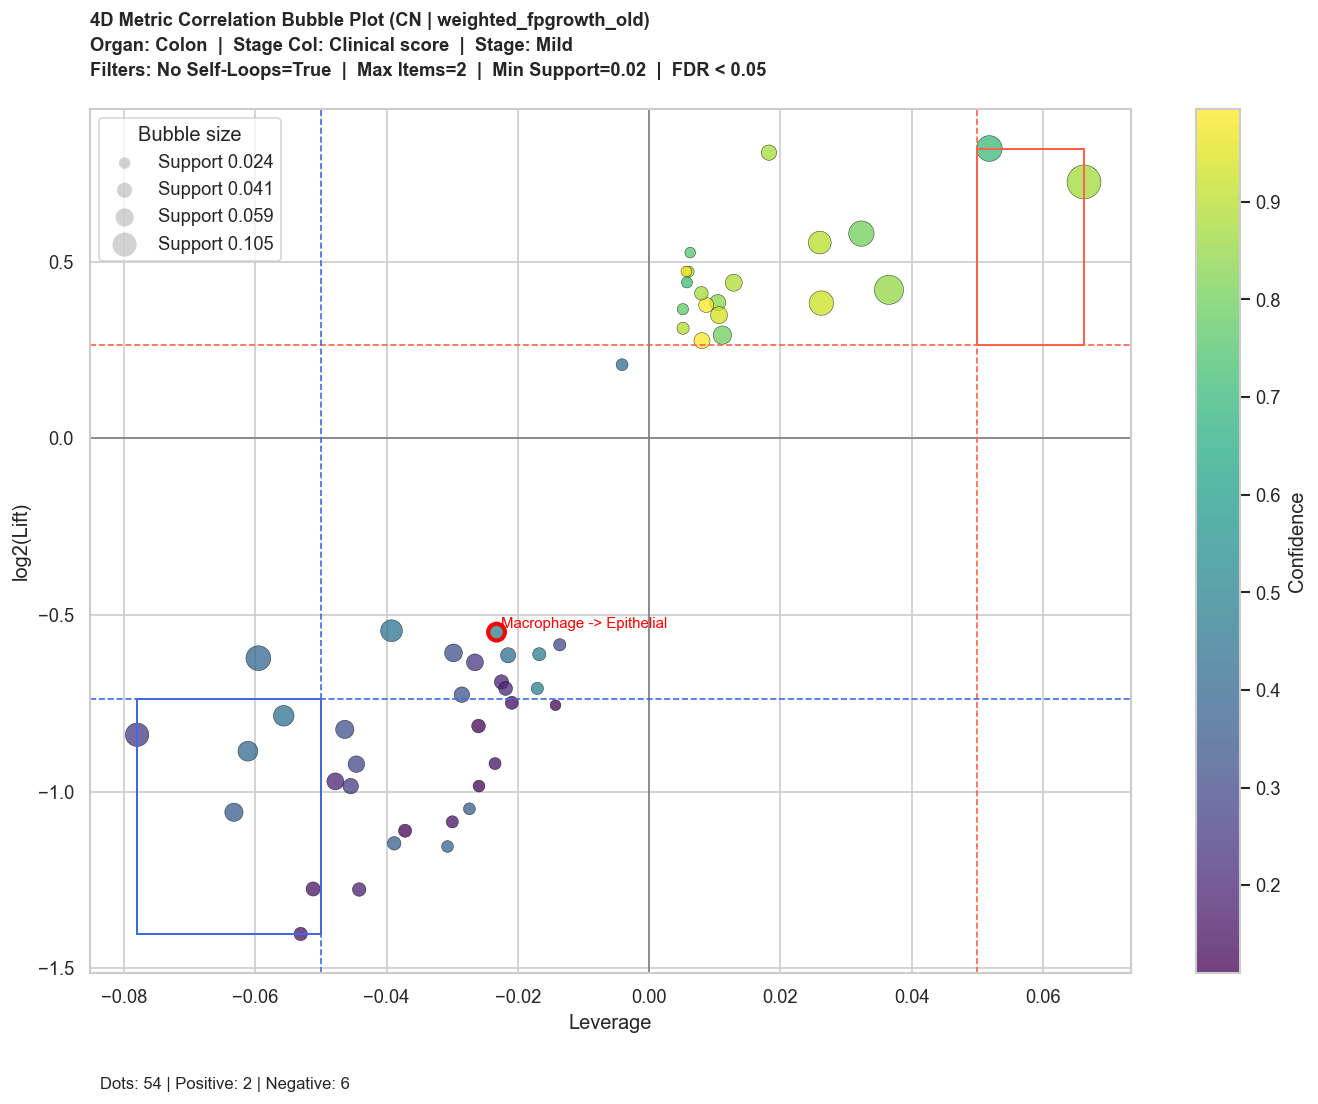

Rules in Positive Zone: 2


,Rule,Leverage,Lift,Log2_Lift,Confidence,Support
8,Epithelial -> Goblet,0.066241,1.653226,0.725284,0.868814,0.206678
31,Macrophage -> SMV,0.051819,1.765275,0.819893,0.706645,0.119532


Rules in Negative Zone: 6


,Rule,Leverage,Lift,Log2_Lift,Confidence,Support
7,Epithelial -> Fibroblast,-0.078012,0.559002,-0.839075,0.252117,0.098886
24,Goblet -> Macrophage,-0.063261,0.480195,-1.058308,0.363648,0.059999
23,Goblet -> Fibroblast,-0.061130,0.541301,-0.885497,0.406307,0.070923
36,Muscle -> Fibroblast,-0.055672,0.580212,-0.785348,0.441533,0.076544
26,Goblet -> SMV,-0.053089,0.378207,-1.402753,0.149870,0.032197
25,Goblet -> Neuron,-0.051193,0.413089,-1.275475,0.148282,0.036138


In [74]:
STAGE = "Mild"  # Update this to test different stages
organ = "Colon"
work_df = _create_basic_dataset(raw_results_df)
metric_df, leverage_source = _build_metric_bubble_df(work_df)

print("filtered work_df:", work_df.shape)
print("metric_df (after FDR + metric filters):", metric_df.shape)
print("leverage_source:", leverage_source)

print(metric_df.head(8))


plot_figure = _plot_metric_bubble(metric_df, leverage_source)
plt.show()

_build_and_display_filtered_zone_dataset(metric_df)

Initial rules count: 65938
Rules count after removing self-overlapping rules: 46016
Rules count after filtering by subset rule items: 5044
Rules count after filtering by minimum support: 3392
Rules count after filtering by stage: 899
Rules count after filtering by organ: 507
metric_df number of lines: 507
filtered work_df: (507, 30)
metric_df (after FDR + metric filters): (98, 8)
leverage_source: mean of per-FOV Leverage
                 Rule      Lift  Confidence   Support  Leverage       FDR  \
0         APC -> CD4T  1.757390    0.873403  0.020410  0.008796  0.001012   
1         APC -> CD8T  1.354886    0.933562  0.021538  0.005641  0.001136   
2   APC -> Macrophage  1.773722    0.946108  0.021416  0.009342  0.001137   
3         CD4T -> APC  2.978194    0.787733  0.029526  0.019612  0.001084   
4        CD4T -> CD8T  1.527179    0.808630  0.049571  0.018529  0.001938   
5  CD4T -> Fibroblast  1.269679    0.896029  0.039380  0.008343  0.001327   
6      CD4T -> Goblet  0.449427    0

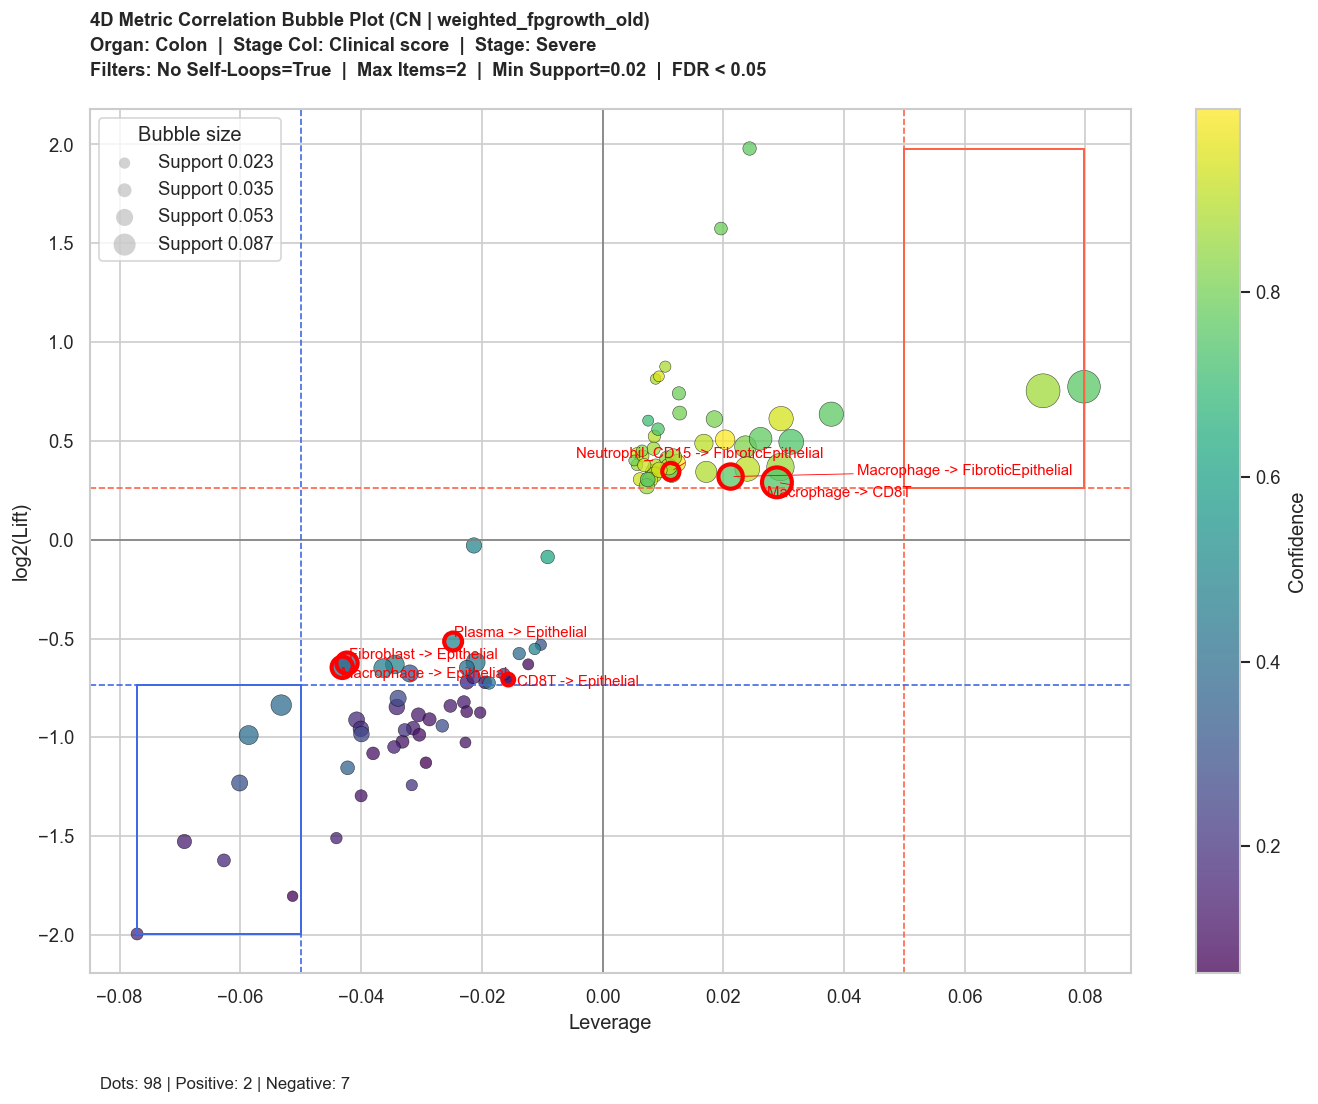

Rules in Positive Zone: 2


,Rule,Leverage,Lift,Log2_Lift,Confidence,Support
77,Neutrophil -> Neutrophil_CD15,0.079757,1.710084,0.774067,0.754244,0.192077
20,Epithelial -> Goblet,0.072975,1.686086,0.753678,0.865536,0.206998


Rules in Negative Zone: 7


,Rule,Leverage,Lift,Log2_Lift,Confidence,Support
66,Muscle -> Epithelial,-0.077106,0.250964,-1.994447,0.158659,0.026237
43,Goblet -> CD4T,-0.069267,0.347048,-1.526791,0.139437,0.037095
51,Goblet -> SMV,-0.062724,0.324803,-1.622362,0.165516,0.030386
48,Goblet -> Macrophage,-0.060119,0.426147,-1.230575,0.293053,0.046922
46,Goblet -> Fibroblast,-0.058626,0.504040,-0.988389,0.397227,0.065756
19,Epithelial -> Fibroblast,-0.053229,0.560010,-0.836475,0.385248,0.076236
49,Goblet -> Neuron,-0.051345,0.286463,-1.803581,0.066810,0.020613


In [75]:
STAGE = "Severe"  # Update this to test different stages
ORGAN = "Colon"
work_df = _create_basic_dataset(raw_results_df)
metric_df, leverage_source = _build_metric_bubble_df(work_df)

print("filtered work_df:", work_df.shape)
print("metric_df (after FDR + metric filters):", metric_df.shape)
print("leverage_source:", leverage_source)

print(metric_df.head(8))


plot_figure = _plot_metric_bubble(metric_df, leverage_source)
plt.show()

_build_and_display_filtered_zone_dataset(metric_df)

## Duodenum's Highest Rules

Initial rules count: 65938
Rules count after removing self-overlapping rules: 46016
Rules count after filtering by subset rule items: 5044
Rules count after filtering by minimum support: 3392
Rules count after filtering by stage: 1074
Rules count after filtering by organ: 374
metric_df number of lines: 374
filtered work_df: (374, 30)
metric_df (after FDR + metric filters): (81, 8)
leverage_source: mean of per-FOV Leverage
                         Rule      Lift  Confidence   Support  Leverage  \
0               Bcell -> CD4T  1.337228    0.986058  0.044641  0.010831   
1         Bcell -> Epithelial  0.360442    0.053960  0.028030 -0.049735   
2        Bcell -> Plasma_CD38  0.429775    0.064635  0.033575 -0.044547   
3        BrunnerGland -> CD4T  0.485083    0.229662  0.023868 -0.025336   
4  BrunnerGland -> Epithelial  0.426726    0.232606  0.024174 -0.032476   
5  BrunnerGland -> Macrophage  0.664130    0.427031  0.044380 -0.022444   
6      BrunnerGland -> Neuron  0.506430    0.2055

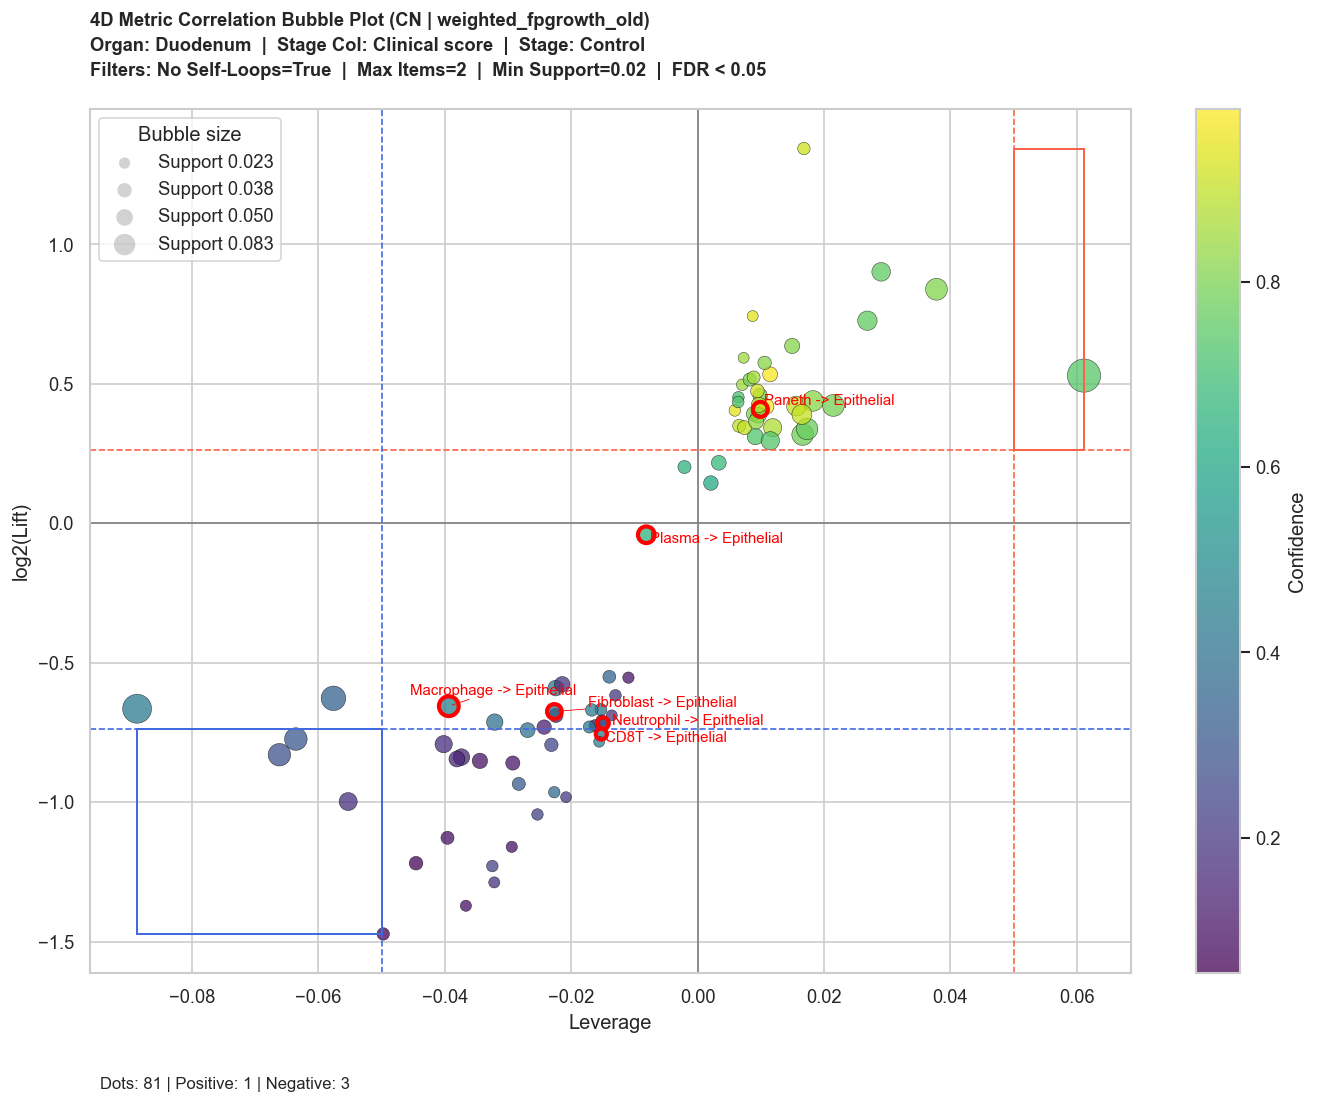

Rules in Positive Zone: 1


,Rule,Leverage,Lift,Log2_Lift,Confidence,Support
24,Epithelial -> Goblet,0.061123,1.443746,0.529817,0.739019,0.198865


Rules in Negative Zone: 3


,Rule,Leverage,Lift,Log2_Lift,Confidence,Support
32,Epithelial -> Plasma,-0.066162,0.562718,-0.829517,0.281662,0.091066
20,Epithelial -> CD4T,-0.063558,0.585080,-0.773295,0.308813,0.091938
34,Epithelial -> SMV,-0.055284,0.500917,-0.997357,0.180054,0.058881


In [76]:
STAGE = "Control"  # Update this to test different stages
ORGAN = "Duodenum" 
work_df = _create_basic_dataset(raw_results_df)
metric_df, leverage_source = _build_metric_bubble_df(work_df)

print("filtered work_df:", work_df.shape)
print("metric_df (after FDR + metric filters):", metric_df.shape)
print("leverage_source:", leverage_source)

print(metric_df.head(8))


plot_figure = _plot_metric_bubble(metric_df, leverage_source)
plt.show()

_build_and_display_filtered_zone_dataset(metric_df)

Initial rules count: 65938
Rules count after removing self-overlapping rules: 46016
Rules count after filtering by subset rule items: 5044
Rules count after filtering by minimum support: 3392
Rules count after filtering by stage: 1419
Rules count after filtering by organ: 1232
metric_df number of lines: 1232
filtered work_df: (1232, 30)
metric_df (after FDR + metric filters): (156, 8)
leverage_source: mean of per-FOV Leverage
                         Rule      Lift  Confidence   Support  Leverage  \
0                 APC -> CD4T  1.327693    0.876246  0.020596  0.005083   
1           APC -> Fibroblast  1.297629    0.909688  0.030382  0.006969   
2        BrunnerGland -> CD4T  0.514515    0.169888  0.027535 -0.029129   
3  BrunnerGland -> Epithelial  0.409351    0.249457  0.053184 -0.076738   
4  BrunnerGland -> Macrophage  0.604215    0.451858  0.059627 -0.036872   
5        BrunnerGland -> Mast  0.671115    0.179867  0.038347 -0.018792   
6      BrunnerGland -> Neuron  0.604434    0.

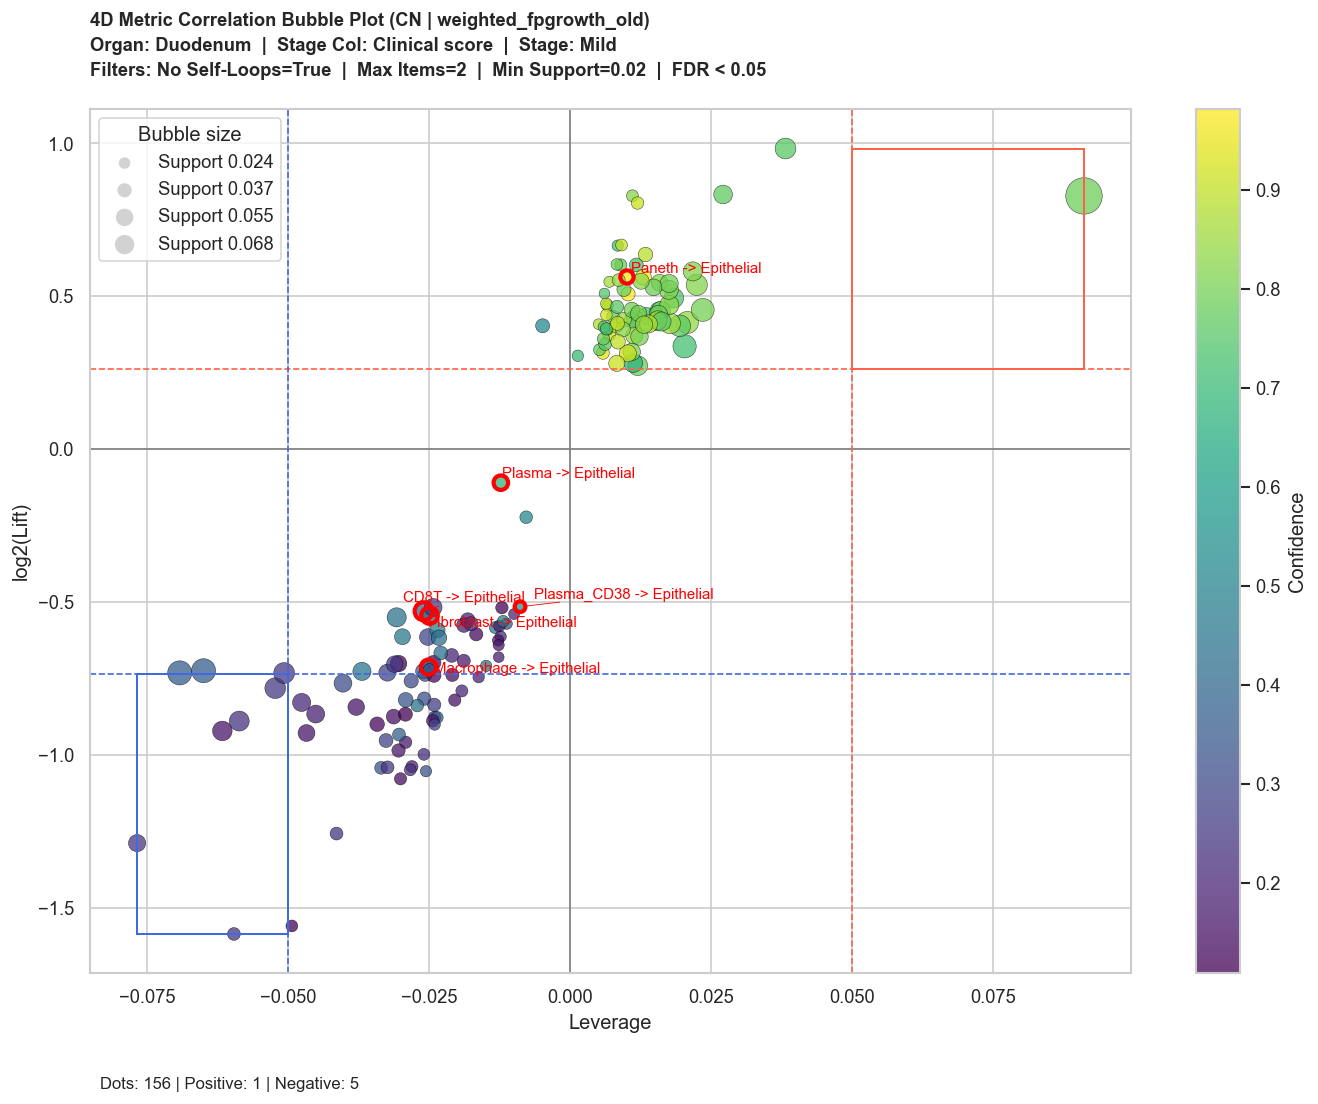

Rules in Positive Zone: 1


,Rule,Leverage,Lift,Log2_Lift,Confidence,Support
42,Epithelial -> Goblet,0.091137,1.775801,0.828470,0.786746,0.239840


Rules in Negative Zone: 5


,Rule,Leverage,Lift,Log2_Lift,Confidence,Support
3,BrunnerGland -> Epithelial,-0.076738,0.409351,-1.288589,0.249457,0.053184
50,Epithelial -> Neutrophil,-0.061626,0.527911,-0.921634,0.158770,0.068913
101,Muscle -> Epithelial,-0.059571,0.333138,-1.585809,0.242703,0.029571
55,Epithelial -> SMV,-0.058629,0.539860,-0.889343,0.238929,0.071565
38,Epithelial -> CD4T,-0.052246,0.581668,-0.781731,0.259871,0.077403


In [77]:
STAGE = "Mild"  # Update this to test different stages
organ = "Duodenum"
work_df = _create_basic_dataset(raw_results_df)
metric_df, leverage_source = _build_metric_bubble_df(work_df)

print("filtered work_df:", work_df.shape)
print("metric_df (after FDR + metric filters):", metric_df.shape)
print("leverage_source:", leverage_source)

print(metric_df.head(8))


plot_figure = _plot_metric_bubble(metric_df, leverage_source)
plt.show()

_build_and_display_filtered_zone_dataset(metric_df)

Initial rules count: 65938
Rules count after removing self-overlapping rules: 46016
Rules count after filtering by subset rule items: 5044
Rules count after filtering by minimum support: 3392
Rules count after filtering by stage: 899
Rules count after filtering by organ: 392
metric_df number of lines: 392
filtered work_df: (392, 30)
metric_df (after FDR + metric filters): (115, 8)
leverage_source: mean of per-FOV Leverage
                         Rule      Lift  Confidence   Support  Leverage  \
0  BrunnerGland -> Epithelial  1.413713    0.879263  0.035934  0.009832   
1  BrunnerGland -> Fibroblast  0.442240    0.321514  0.027886 -0.034565   
2  BrunnerGland -> Macrophage  0.586036    0.501018  0.035082 -0.026438   
3                CD4T -> CD8T  1.443716    0.858132  0.029492  0.009253   
4          CD4T -> Fibroblast  1.554692    0.833622  0.026440  0.009514   
5         CD4T -> ImmuneOther  1.431228    0.847523  0.020900  0.006297   
6          CD4T -> Macrophage  1.419474    0.8933

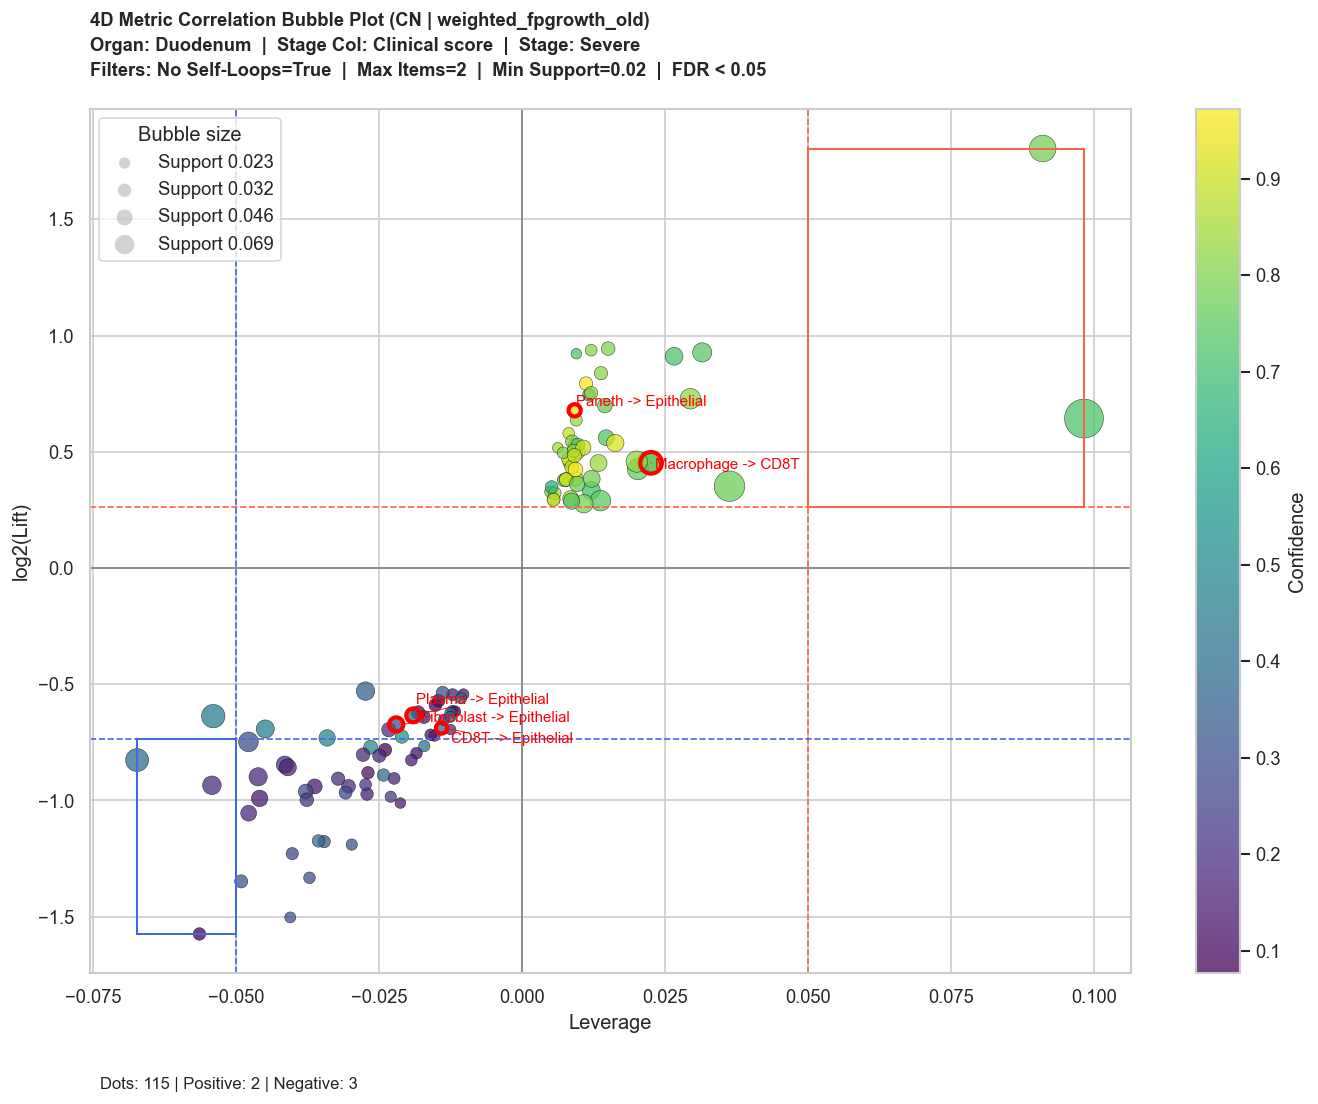

Rules in Positive Zone: 2


,Rule,Leverage,Lift,Log2_Lift,Confidence,Support
22,Epithelial -> Goblet,0.098314,1.561576,0.643003,0.721658,0.273383
31,Epithelial -> Paneth,0.091093,3.493841,1.804814,0.780981,0.127620


Rules in Negative Zone: 3


,Rule,Leverage,Lift,Log2_Lift,Confidence,Support
21,Epithelial -> Fibroblast,-0.067279,0.564018,-0.826186,0.386260,0.095360
28,Epithelial -> Muscle,-0.056370,0.335778,-1.574420,0.076790,0.028496
34,Epithelial -> SMV,-0.054201,0.523151,-0.934701,0.196474,0.062722


In [78]:
STAGE = "Severe"  # Update this to test different stages
ORGAN = "Duodenum"
work_df = _create_basic_dataset(raw_results_df)
metric_df, leverage_source = _build_metric_bubble_df(work_df)

print("filtered work_df:", work_df.shape)
print("metric_df (after FDR + metric filters):", metric_df.shape)
print("leverage_source:", leverage_source)

print(metric_df.head(8))


plot_figure = _plot_metric_bubble(metric_df, leverage_source)
plt.show()

_build_and_display_filtered_zone_dataset(metric_df)

In [79]:
zone_summary_df = _summarize_threshold_zones(metric_df)
display(zone_summary_df)

print('\nMean values of the wanted subset:')
display(metric_df[["Leverage", "Lift", "Log2_Lift", "Confidence", "Support"]].mean().to_frame(name="Mean"))


,Zone,Count,Percent
0,Positive zone,2,1.74
1,Negative zone,3,2.61
2,Noise zone,0,0.00
3,Total,115,100.00



Mean values of the wanted subset:


,Mean
Leverage,-0.007798
Lift,0.997746
Log2_Lift,-0.190715
Confidence,0.516311
Support,0.042152


## Automated Manager Report Generation
Run this cell to automatically generate a multi-page PDF containing bubble plots and highlight tables.

In [80]:
import glob
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt

# 1. Define combinations
organs_to_run = ["Colon", "Duodenum"]
stages_to_run = ["Control", "Mild", "Severe"]

# 2. Find next running ID
existing_reports = glob.glob("reports/bubble_metrics_report_*.pdf")
ids = []
for f in existing_reports:
    try:
        num_str = f.split("_")[-1].replace(".pdf", "")
        ids.append(int(num_str))
    except ValueError:
        pass
next_id = max(ids) + 1 if ids else 1

report_filename = f"reports/bubble_metrics_report_{next_id:03d}.pdf"
print(f"Generating PDF Report: {report_filename}...")

# 3. Create PDF
with PdfPages(report_filename) as pdf:
    for organ in organs_to_run:
        
        # A. Plot Bubble Charts per Stage
        for stage in stages_to_run:
            print(f"-> Processing Organ: {organ} | Stage: {stage}")
            
            ORGAN = organ
            STAGE = stage
            
            work_df = _create_basic_dataset(raw_results_df)
            if not work_df.empty:
                metric_df, leverage_source = _build_metric_bubble_df(work_df)
                if not metric_df.empty:
                    fig = _plot_metric_bubble(metric_df, leverage_source)
                    if fig is not None:
                        pdf.savefig(fig, bbox_inches='tight')
                        plt.close(fig)
        
        # B. Append the Highlighted Rules Summary Table at the end of the organ's section
        print(f"-> Appending Highlighted Rules Table for Organ: {organ}")
        table_fig = _plot_highlight_rules_table(organ)
        if table_fig is not None:
            pdf.savefig(table_fig, bbox_inches='tight')
            plt.close(table_fig)

print("✅ PDF Report Generation Complete!")

Generating PDF Report: reports/bubble_metrics_report_005.pdf...
-> Processing Organ: Colon | Stage: Control
Initial rules count: 65938
Rules count after removing self-overlapping rules: 46016
Rules count after filtering by subset rule items: 5044
Rules count after filtering by minimum support: 3392
Rules count after filtering by stage: 1074
Rules count after filtering by organ: 323
metric_df number of lines: 323
-> Processing Organ: Colon | Stage: Mild
Initial rules count: 65938
Rules count after removing self-overlapping rules: 46016
Rules count after filtering by subset rule items: 5044
Rules count after filtering by minimum support: 3392
Rules count after filtering by stage: 1419
Rules count after filtering by organ: 187
metric_df number of lines: 187
-> Processing Organ: Colon | Stage: Severe
Initial rules count: 65938
Rules count after removing self-overlapping rules: 46016
Rules count after filtering by subset rule items: 5044
Rules count after filtering by minimum support: 3392
